# 08b — ProteinMPNN Structure-Conditioned Peptide Design

## Pipeline 4 — Protein Language Models and AI-guided Peptide Design

This notebook introduces **ProteinMPNN** into PEARL.

The design target is the receptor–peptide complex:

```text
receptor = chain B
peptide  = chain D
```

with the natural miniaturized reference:

```text
F0010 = IGERCQYRDLK
```

The aim is:

> Generate peptide sequences that are compatible with the bound receptor–peptide backbone while preserving the most strongly supported interface hotspot positions.

---

## PEARL design logic

From Pipeline 3, the following F0010 residues received joint FoldX + MD support:

```text
sequence position    residue
2                    G39
4                    R41
6                    Q43
7                    Y44
8                    R45
10                   L47
```

These positions are therefore **fixed** during the main ProteinMPNN run.

ProteinMPNN is allowed to redesign:

```text
positions 1, 3, 5, 9, 11
```

This is especially useful because the successful CLEAR mutations occur in this mutable set:

```text
CF02: C5S + D9E
CF06: D9E + K11R
```

---

## Important interpretation

ProteinMPNN performs **structure-conditioned inverse folding**.

It asks:

> Which amino-acid sequences are compatible with this receptor–peptide backbone?

It does **not** directly predict binding affinity or inhibitory activity.

The strongest evidence will come from convergence among:

```text
ProteinMPNN
+ ESM-2
+ CLEAR
+ Rosetta/FoldX
+ MD
+ endpoint energetic analysis
```


## 1. Environment check

In [1]:
import sys
from pathlib import Path

print("Python:", sys.version)
print("Working directory:", Path.cwd())

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as exc:
    raise RuntimeError(
        f"PyTorch is required for ProteinMPNN: {exc}"
    )

print("Environment check: PASS")


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv
PyTorch: 2.13.0
Environment check: PASS


### Recommended kernel

Use the same AI environment as notebook 08a:

```text
Python (PEARL AI)
```

No separate ProteinMPNN environment is required if PyTorch already works there.


## 2. Imports

In [2]:
import json
import shutil
import subprocess
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Imports OK")


Imports OK


## 3. Configuration

In [3]:
# ------------------------------------------------------
# ProteinMPNN repository
# ------------------------------------------------------
PROTEINMPNN_REPO = (
    Path("tools")
    / "ProteinMPNN"
)

PROTEINMPNN_GIT_URL = (
    "https://github.com/dauparas/ProteinMPNN.git"
)

AUTO_CLONE_IF_MISSING = True

# ------------------------------------------------------
# PEARL bound structure
# ------------------------------------------------------
INPUT_PDB = (
    Path("outputs")
    / "clear_local_peptide_dataset_04c"
    / "foldx_buildmodel"
    / "F0010_native_complex.pdb"
)

RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"

F0010_SEQUENCE = "IGERCQYRDLK"

# ProteinMPNN uses sequence positions within the chain,
# starting from 1.
FIXED_PEPTIDE_POSITIONS = [
    2, 4, 6, 7, 8, 10
]

DESIGNABLE_PEPTIDE_POSITIONS = [
    1, 3, 5, 9, 11
]

# ------------------------------------------------------
# Sampling
# ------------------------------------------------------
FAST_TEST_MODE = False

if FAST_TEST_MODE:
    NUM_SEQ_PER_TARGET = 10
    SAMPLING_TEMPERATURES = "0.1"
else:
    NUM_SEQ_PER_TARGET = 50
    SAMPLING_TEMPERATURES = "0.1 0.2"

BATCH_SIZE = 1
RANDOM_SEED = 20260810

MODEL_NAME = "v_48_020"

# ------------------------------------------------------
# Output
# ------------------------------------------------------
RUN_LABEL = (
    "test"
    if FAST_TEST_MODE
    else "production"
)

OUTPUT_ROOT = (
    Path("outputs")
    / "pipeline_4_ai_08b_proteinmpnn"
    / RUN_LABEL
)

INPUT_DIR = OUTPUT_ROOT / "input_pdb"
HELPER_DIR = OUTPUT_ROOT / "helper_jsonl"
MPNN_OUT_DIR = OUTPUT_ROOT / "proteinmpnn_output"
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    OUTPUT_ROOT,
    INPUT_DIR,
    HELPER_DIR,
    MPNN_OUT_DIR,
    TABLE_DIR,
    REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_TEST_MODE:", FAST_TEST_MODE)
print("Input PDB:", INPUT_PDB)
print("Fixed positions:", FIXED_PEPTIDE_POSITIONS)
print("Designable positions:", DESIGNABLE_PEPTIDE_POSITIONS)
print("Output:", OUTPUT_ROOT.resolve())


FAST_TEST_MODE: False
Input PDB: outputs/clear_local_peptide_dataset_04c/foldx_buildmodel/F0010_native_complex.pdb
Fixed positions: [2, 4, 6, 7, 8, 10]
Designable positions: [1, 3, 5, 9, 11]
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08b_proteinmpnn/production


## 4. Check or clone ProteinMPNN

In [4]:
if not PROTEINMPNN_REPO.exists():

    if not AUTO_CLONE_IF_MISSING:
        raise FileNotFoundError(
            "ProteinMPNN repository not found. "
            "Clone it into tools/ProteinMPNN."
        )

    PROTEINMPNN_REPO.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "ProteinMPNN repository not found."
    )
    print(
        "Cloning official repository..."
    )

    result = subprocess.run(
        [
            "git",
            "clone",
            PROTEINMPNN_GIT_URL,
            str(PROTEINMPNN_REPO),
        ],
        text=True,
        capture_output=True,
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(
            "ProteinMPNN git clone failed."
        )

required_repo_files = [
    PROTEINMPNN_REPO
    / "protein_mpnn_run.py",
    PROTEINMPNN_REPO
    / "protein_mpnn_utils.py",
    PROTEINMPNN_REPO
    / "helper_scripts"
    / "parse_multiple_chains.py",
    PROTEINMPNN_REPO
    / "helper_scripts"
    / "assign_fixed_chains.py",
    PROTEINMPNN_REPO
    / "helper_scripts"
    / "make_fixed_positions_dict.py",
]

repo_check = pd.DataFrame([
    {
        "path": str(path),
        "exists": path.exists(),
    }
    for path in required_repo_files
])

display(repo_check)

if not repo_check["exists"].all():
    raise FileNotFoundError(
        "ProteinMPNN repository is incomplete."
    )

print("ProteinMPNN repository check: PASS")


,path,exists
0,tools/ProteinMPNN/protein_mpnn_run.py,True
1,tools/ProteinMPNN/protein_mpnn_utils.py,True
2,tools/ProteinMPNN/helper_scripts/parse_multipl...,True
3,tools/ProteinMPNN/helper_scripts/assign_fixed_...,True
4,tools/ProteinMPNN/helper_scripts/make_fixed_po...,True


ProteinMPNN repository check: PASS


## 5. Record ProteinMPNN git version

In [5]:
git_hash_result = subprocess.run(
    [
        "git",
        "-C",
        str(PROTEINMPNN_REPO),
        "rev-parse",
        "HEAD",
    ],
    text=True,
    capture_output=True,
)

PROTEINMPNN_GIT_HASH = (
    git_hash_result.stdout.strip()
    if git_hash_result.returncode == 0
    else "unknown"
)

print(
    "ProteinMPNN git hash:",
    PROTEINMPNN_GIT_HASH,
)


ProteinMPNN git hash: 8907e6671bfbfc92303b5f79c4b5e6ce47cdef57


## 6. Validate the PEARL input structure

In [6]:
if not INPUT_PDB.exists():
    raise FileNotFoundError(
        f"Input PDB not found: {INPUT_PDB}"
    )

# Simple PDB parser sufficient for chain/sequence validation.
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

def pdb_chain_sequence(
    pdb_path,
    chain_id,
):
    residues = []
    seen = set()

    with open(
        pdb_path,
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as handle:

        for line in handle:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()

            if chain != chain_id:
                continue

            resname = line[17:20].strip()
            resid = (
                line[22:26].strip(),
                line[26].strip(),
            )

            key = (
                chain,
                resid,
            )

            if key in seen:
                continue

            seen.add(key)

            if resname in THREE_TO_ONE:
                residues.append(
                    THREE_TO_ONE[resname]
                )

    return "".join(
        residues
    )

observed_peptide_sequence = (
    pdb_chain_sequence(
        INPUT_PDB,
        PEPTIDE_CHAIN,
    )
)

observed_receptor_sequence = (
    pdb_chain_sequence(
        INPUT_PDB,
        RECEPTOR_CHAIN,
    )
)

print(
    "Chain B length:",
    len(observed_receptor_sequence),
)
print(
    "Chain D sequence:",
    observed_peptide_sequence,
)

if observed_peptide_sequence != F0010_SEQUENCE:
    raise RuntimeError(
        "Chain D does not match F0010. "
        f"Observed: {observed_peptide_sequence}"
    )

print("Input structure validation: PASS")


Chain B length: 614
Chain D sequence: IGERCQYRDLK
Input structure validation: PASS


## 7. Validate fixed/designable positions

In [7]:
all_positions = set(
    range(
        1,
        len(F0010_SEQUENCE) + 1,
    )
)

fixed_set = set(
    FIXED_PEPTIDE_POSITIONS
)

designable_set = set(
    DESIGNABLE_PEPTIDE_POSITIONS
)

assert fixed_set.isdisjoint(
    designable_set
)

assert (
    fixed_set
    | designable_set
) == all_positions

position_table = pd.DataFrame([
    {
        "position": pos,
        "F0010_aa": F0010_SEQUENCE[
            pos - 1
        ],
        "status": (
            "FIXED_hotspot"
            if pos in fixed_set
            else "DESIGNABLE"
        ),
    }
    for pos in range(
        1,
        len(F0010_SEQUENCE) + 1,
    )
])

display(position_table)

position_table.to_csv(
    TABLE_DIR
    / "08b_design_position_map.csv",
    index=False,
)


,position,F0010_aa,status
0,1,I,DESIGNABLE
1,2,G,FIXED_hotspot
2,3,E,DESIGNABLE
3,4,R,FIXED_hotspot
4,5,C,DESIGNABLE
5,6,Q,FIXED_hotspot
6,7,Y,FIXED_hotspot
7,8,R,FIXED_hotspot
8,9,D,DESIGNABLE
9,10,L,FIXED_hotspot


## 8. Prepare the ProteinMPNN input folder

ProteinMPNN's official multi-chain helper scripts operate on a folder of PDBs.

We therefore copy the PEARL F0010 complex into a dedicated notebook output
directory under a simple target name.


In [8]:
TARGET_NAME = "PEARL_F0010_BD"

TARGET_PDB = (
    INPUT_DIR
    / f"{TARGET_NAME}.pdb"
)

shutil.copy2(
    INPUT_PDB,
    TARGET_PDB,
)

print("Prepared:", TARGET_PDB)


Prepared: outputs/pipeline_4_ai_08b_proteinmpnn/production/input_pdb/PEARL_F0010_BD.pdb


## 9. Define helper JSONL paths

In [9]:
PARSED_JSONL = (
    HELPER_DIR
    / "parsed_pdbs.jsonl"
)

ASSIGNED_CHAINS_JSONL = (
    HELPER_DIR
    / "assigned_chains.jsonl"
)

FIXED_POSITIONS_JSONL = (
    HELPER_DIR
    / "fixed_positions.jsonl"
)

print(PARSED_JSONL)
print(ASSIGNED_CHAINS_JSONL)
print(FIXED_POSITIONS_JSONL)


outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/parsed_pdbs.jsonl
outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/assigned_chains.jsonl
outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/fixed_positions.jsonl


## 10. Run official PDB parser

In [10]:
cmd_parse = [
    sys.executable,
    str(
        PROTEINMPNN_REPO
        / "helper_scripts"
        / "parse_multiple_chains.py"
    ),
    "--input_path",
    str(INPUT_DIR),
    "--output_path",
    str(PARSED_JSONL),
]

print(
    " ".join(cmd_parse)
)

result = subprocess.run(
    cmd_parse,
    text=True,
    capture_output=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "ProteinMPNN PDB parsing failed."
    )

if not PARSED_JSONL.exists():
    raise FileNotFoundError(
        "parsed_pdbs.jsonl was not created."
    )

print("PDB parsing: PASS")


/Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python tools/ProteinMPNN/helper_scripts/parse_multiple_chains.py --input_path outputs/pipeline_4_ai_08b_proteinmpnn/production/input_pdb --output_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/parsed_pdbs.jsonl

PDB parsing: PASS


## 11. Assign chain D as designed and chain B as fixed

In [11]:
CHAINS_TO_DESIGN = PEPTIDE_CHAIN

cmd_assign = [
    sys.executable,
    str(
        PROTEINMPNN_REPO
        / "helper_scripts"
        / "assign_fixed_chains.py"
    ),
    "--input_path",
    str(PARSED_JSONL),
    "--output_path",
    str(ASSIGNED_CHAINS_JSONL),
    "--chain_list",
    CHAINS_TO_DESIGN,
]

print(
    " ".join(cmd_assign)
)

result = subprocess.run(
    cmd_assign,
    text=True,
    capture_output=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "ProteinMPNN chain assignment failed."
    )

print(
    ASSIGNED_CHAINS_JSONL.read_text(
        encoding="utf-8"
    )
)


/Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python tools/ProteinMPNN/helper_scripts/assign_fixed_chains.py --input_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/parsed_pdbs.jsonl --output_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/assigned_chains.jsonl --chain_list D

{"PEARL_F0010_BD": [["D"], ["B"]]}



## 12. Fix the supported F0010 hotspot positions

In [12]:
FIXED_POSITIONS_STRING = " ".join(
    str(x)
    for x in FIXED_PEPTIDE_POSITIONS
)

cmd_fixed = [
    sys.executable,
    str(
        PROTEINMPNN_REPO
        / "helper_scripts"
        / "make_fixed_positions_dict.py"
    ),
    "--input_path",
    str(PARSED_JSONL),
    "--output_path",
    str(FIXED_POSITIONS_JSONL),
    "--chain_list",
    CHAINS_TO_DESIGN,
    "--position_list",
    FIXED_POSITIONS_STRING,
]

print(
    " ".join(cmd_fixed)
)

result = subprocess.run(
    cmd_fixed,
    text=True,
    capture_output=True,
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "ProteinMPNN fixed-position setup failed."
    )

print(
    FIXED_POSITIONS_JSONL.read_text(
        encoding="utf-8"
    )
)


/Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python tools/ProteinMPNN/helper_scripts/make_fixed_positions_dict.py --input_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/parsed_pdbs.jsonl --output_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/fixed_positions.jsonl --chain_list D --position_list 2 4 6 7 8 10

{"PEARL_F0010_BD": {"D": [2, 4, 6, 7, 8, 10], "B": []}}



## 13. Inspect the generated helper dictionaries

Before running ProteinMPNN, verify that:

```text
designed chain = D
fixed chain    = B
fixed D positions = 2,4,6,7,8,10
```

The notebook checks this programmatically where possible.


In [13]:
with open(
    ASSIGNED_CHAINS_JSONL,
    "r",
    encoding="utf-8",
) as handle:
    assigned_lines = [
        json.loads(line)
        for line in handle
        if line.strip()
    ]

with open(
    FIXED_POSITIONS_JSONL,
    "r",
    encoding="utf-8",
) as handle:
    fixed_lines = [
        json.loads(line)
        for line in handle
        if line.strip()
    ]

print("Assigned-chain dictionary:")
display(
    pd.DataFrame([
        {
            "dictionary": obj
        }
        for obj in assigned_lines
    ])
)

print("Fixed-position dictionary:")
display(
    pd.DataFrame([
        {
            "dictionary": obj
        }
        for obj in fixed_lines
    ])
)


Assigned-chain dictionary:


,dictionary
0,"{'PEARL_F0010_BD': [['D'], ['B']]}"


Fixed-position dictionary:


,dictionary
0,"{'PEARL_F0010_BD': {'D': [2, 4, 6, 7, 8, 10], ..."


## 14. Run ProteinMPNN

In [14]:
cmd_mpnn = [
    sys.executable,
    str(
        PROTEINMPNN_REPO
        / "protein_mpnn_run.py"
    ),
    "--jsonl_path",
    str(PARSED_JSONL),
    "--chain_id_jsonl",
    str(ASSIGNED_CHAINS_JSONL),
    "--fixed_positions_jsonl",
    str(FIXED_POSITIONS_JSONL),
    "--out_folder",
    str(MPNN_OUT_DIR),
    "--num_seq_per_target",
    str(NUM_SEQ_PER_TARGET),
    "--sampling_temp",
    SAMPLING_TEMPERATURES,
    "--seed",
    str(RANDOM_SEED),
    "--batch_size",
    str(BATCH_SIZE),
    "--model_name",
    MODEL_NAME,
    "--save_score",
    "1",
]

print("ProteinMPNN command:")
print(
    " ".join(cmd_mpnn)
)

result = subprocess.run(
    cmd_mpnn,
    text=True,
    capture_output=True,
)

print(result.stdout)

if result.returncode != 0:
    print(
        "\nSTDERR:\n",
        result.stderr,
    )

    raise RuntimeError(
        "ProteinMPNN execution failed."
    )

print("ProteinMPNN execution: PASS")


ProteinMPNN command:
/Users/robertobruzzese/miniforge3/envs/pearl-ai/bin/python tools/ProteinMPNN/protein_mpnn_run.py --jsonl_path outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/parsed_pdbs.jsonl --chain_id_jsonl outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/assigned_chains.jsonl --fixed_positions_jsonl outputs/pipeline_4_ai_08b_proteinmpnn/production/helper_jsonl/fixed_positions.jsonl --out_folder outputs/pipeline_4_ai_08b_proteinmpnn/production/proteinmpnn_output --num_seq_per_target 50 --sampling_temp 0.1 0.2 --seed 20260810 --batch_size 1 --model_name v_48_020 --save_score 1
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----

## 15. Locate generated FASTA files

In [15]:
fasta_files = sorted(
    (MPNN_OUT_DIR / "seqs")
    .glob("*.fa")
)

print(
    "FASTA files found:",
    len(fasta_files),
)

for path in fasta_files:
    print(path)

if not fasta_files:
    raise FileNotFoundError(
        "No ProteinMPNN FASTA output was found."
    )


FASTA files found: 1
outputs/pipeline_4_ai_08b_proteinmpnn/production/proteinmpnn_output/seqs/PEARL_F0010_BD.fa


## 16. Parse ProteinMPNN FASTA output

In [16]:
def parse_mpnn_fasta(
    path,
):
    records = []

    header = None
    seq_parts = []

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as handle:

        for raw_line in handle:
            line = raw_line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    records.append(
                        (
                            header,
                            "".join(seq_parts),
                        )
                    )

                header = line[1:]
                seq_parts = []

            else:
                seq_parts.append(
                    line
                )

        if header is not None:
            records.append(
                (
                    header,
                    "".join(seq_parts),
                )
            )

    return records


all_records = []

for fasta_path in fasta_files:

    for header, full_sequence in parse_mpnn_fasta(
        fasta_path
    ):
        all_records.append({
            "fasta_file": str(fasta_path),
            "header": header,
            "full_sequence": full_sequence,
        })

records_df = pd.DataFrame(
    all_records
)

print(
    "FASTA records:",
    len(records_df),
)

display(
    records_df.head(10)
)


FASTA records: 101


,fasta_file,header,full_sequence
0,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"PEARL_F0010_BD, score=2.6471, global_score=1.5...",IGERCQYRDLK
1,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=1, score=1.3046, global_score=1....",TGPRNQYRDLP
2,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=2, score=1.3172, global_score=1....",TGPRNQYRDLN
3,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=3, score=1.3137, global_score=1....",TGPRNQYRDLN
4,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=4, score=1.2893, global_score=1....",TGPRNQYRDLN
5,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=5, score=1.2528, global_score=1....",TGPRNQYRDLP
6,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=6, score=1.2910, global_score=1....",TGPRNQYRDLP
7,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=7, score=1.3512, global_score=1....",TGPRNQYRDLP
8,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=8, score=1.3831, global_score=1....",TGPRNQYRDLT
9,outputs/pipeline_4_ai_08b_proteinmpnn/producti...,"T=0.1, sample=9, score=1.6005, global_score=1....",EGPRNQYRDLP


## 17. Extract the designed chain-D sequence

ProteinMPNN multi-chain FASTA sequences are separated by `/`.

The helper-parsed target preserves the protein complex chain order.

This cell identifies the F0010-like 11-residue component and checks that it is
the designed peptide.


In [17]:
def extract_peptide_component(
    full_sequence,
    expected_length=11,
):
    parts = full_sequence.split("/")

    length_matches = [
        part
        for part in parts
        if len(part) == expected_length
    ]

    if len(length_matches) == 1:
        return length_matches[0]

    # If the output contains only the designed chain.
    if (
        len(parts) == 1
        and len(parts[0]) == expected_length
    ):
        return parts[0]

    return None


records_df[
    "peptide_sequence"
] = records_df[
    "full_sequence"
].apply(
    extract_peptide_component
)

display(
    records_df[
        [
            "header",
            "peptide_sequence",
        ]
    ].head(20)
)

if records_df[
    "peptide_sequence"
].isna().any():

    problem_rows = records_df[
        records_df[
            "peptide_sequence"
        ].isna()
    ]

    display(problem_rows)

    raise RuntimeError(
        "Could not extract an 11-aa chain-D peptide "
        "from one or more ProteinMPNN records."
    )


,header,peptide_sequence
0,"PEARL_F0010_BD, score=2.6471, global_score=1.5...",IGERCQYRDLK
1,"T=0.1, sample=1, score=1.3046, global_score=1....",TGPRNQYRDLP
2,"T=0.1, sample=2, score=1.3172, global_score=1....",TGPRNQYRDLN
3,"T=0.1, sample=3, score=1.3137, global_score=1....",TGPRNQYRDLN
4,"T=0.1, sample=4, score=1.2893, global_score=1....",TGPRNQYRDLN
5,"T=0.1, sample=5, score=1.2528, global_score=1....",TGPRNQYRDLP
6,"T=0.1, sample=6, score=1.2910, global_score=1....",TGPRNQYRDLP
7,"T=0.1, sample=7, score=1.3512, global_score=1....",TGPRNQYRDLP
8,"T=0.1, sample=8, score=1.3831, global_score=1....",TGPRNQYRDLT
9,"T=0.1, sample=9, score=1.6005, global_score=1....",EGPRNQYRDLP


## 18. Separate native/reference record from generated samples

In [18]:
def header_value(
    header,
    key,
):
    match = re.search(
        rf"{re.escape(key)}=([^,\s]+)",
        header,
    )

    return (
        match.group(1)
        if match
        else None
    )


records_df["sample"] = (
    records_df["header"]
    .apply(
        lambda x: header_value(
            x,
            "sample",
        )
    )
)

records_df["score"] = pd.to_numeric(
    records_df["header"].apply(
        lambda x: header_value(
            x,
            "score",
        )
    ),
    errors="coerce",
)

records_df["global_score"] = pd.to_numeric(
    records_df["header"].apply(
        lambda x: header_value(
            x,
            "global_score",
        )
    ),
    errors="coerce",
)

records_df["temperature"] = pd.to_numeric(
    records_df["header"].apply(
        lambda x: header_value(
            x,
            "T",
        )
    ),
    errors="coerce",
)

records_df["is_generated"] = (
    records_df["sample"].notna()
)

generated_df = (
    records_df[
        records_df["is_generated"]
    ]
    .copy()
)

print(
    "Generated records:",
    len(generated_df),
)

display(
    generated_df[
        [
            "sample",
            "temperature",
            "score",
            "global_score",
            "peptide_sequence",
        ]
    ].head(20)
)


Generated records: 100


,sample,temperature,score,global_score,peptide_sequence
1,1,0.1,1.3046,1.5487,TGPRNQYRDLP
2,2,0.1,1.3172,1.5480,TGPRNQYRDLN
3,3,0.1,1.3137,1.5471,TGPRNQYRDLN
4,4,0.1,1.2893,1.5426,TGPRNQYRDLN
5,5,0.1,1.2528,1.5451,TGPRNQYRDLP
6,6,0.1,1.2910,1.5513,TGPRNQYRDLP
7,7,0.1,1.3512,1.5296,TGPRNQYRDLP
8,8,0.1,1.3831,1.5535,TGPRNQYRDLT
9,9,0.1,1.6005,1.5521,EGPRNQYRDLP
10,10,0.1,1.3576,1.5574,TGPRNQYRDLS


## 19. Verify that fixed hotspot positions were actually preserved

In [19]:
fixed_validation_rows = []

for _, row in generated_df.iterrows():

    seq = row[
        "peptide_sequence"
    ]

    preserved_positions = []

    violations = []

    for pos in FIXED_PEPTIDE_POSITIONS:

        expected = F0010_SEQUENCE[
            pos - 1
        ]

        observed = seq[
            pos - 1
        ]

        if observed == expected:
            preserved_positions.append(
                pos
            )
        else:
            violations.append({
                "position": pos,
                "expected": expected,
                "observed": observed,
            })

    fixed_validation_rows.append({
        "peptide_sequence": seq,
        "n_fixed_positions_preserved": len(
            preserved_positions
        ),
        "all_fixed_positions_preserved": (
            len(violations) == 0
        ),
        "violations": str(
            violations
        ),
    })

fixed_validation_df = pd.DataFrame(
    fixed_validation_rows
)

display(
    fixed_validation_df.head(20)
)

if not fixed_validation_df[
    "all_fixed_positions_preserved"
].all():

    raise RuntimeError(
        "ProteinMPNN changed one or more supposedly fixed hotspot positions. "
        "Do not use these designs until the chain/fixed-position setup is corrected."
    )

print(
    "Fixed hotspot preservation: PASS"
)


,peptide_sequence,n_fixed_positions_preserved,all_fixed_positions_preserved,violations
0,TGPRNQYRDLP,6,True,[]
1,TGPRNQYRDLN,6,True,[]
2,TGPRNQYRDLN,6,True,[]
3,TGPRNQYRDLN,6,True,[]
4,TGPRNQYRDLP,6,True,[]
5,TGPRNQYRDLP,6,True,[]
6,TGPRNQYRDLP,6,True,[]
7,TGPRNQYRDLT,6,True,[]
8,EGPRNQYRDLP,6,True,[]
9,TGPRNQYRDLS,6,True,[]


Fixed hotspot preservation: PASS


## 20. Sequence-level design metrics

In [20]:
def hamming_distance(
    a,
    b,
):
    if len(a) != len(b):
        return np.nan

    return sum(
        aa != bb
        for aa, bb in zip(a, b)
    )


generated_df[
    "hamming_vs_F0010"
] = generated_df[
    "peptide_sequence"
].apply(
    lambda seq: hamming_distance(
        seq,
        F0010_SEQUENCE,
    )
)

generated_df[
    "matches_CF06"
] = (
    generated_df[
        "peptide_sequence"
    ]
    == "IGERCQYRELR"
)

generated_df[
    "matches_CF02"
] = (
    generated_df[
        "peptide_sequence"
    ]
    == "IGERSQYRELK"
)

generated_df[
    "matches_F0010"
] = (
    generated_df[
        "peptide_sequence"
    ]
    == F0010_SEQUENCE
)

generated_df.to_csv(
    TABLE_DIR
    / "08b_ProteinMPNN_generated_sequences_raw.csv",
    index=False,
)

display(
    generated_df[
        [
            "peptide_sequence",
            "score",
            "global_score",
            "temperature",
            "hamming_vs_F0010",
            "matches_F0010",
            "matches_CF06",
            "matches_CF02",
        ]
    ]
    .sort_values(
        "score",
        ascending=True,
    )
    .head(30)
)


,peptide_sequence,score,global_score,temperature,hamming_vs_F0010,matches_F0010,matches_CF06,matches_CF02
79,TGPRNQYRDLP,1.2473,1.5532,0.2,4,False,False,False
69,TGPRNQYRDLN,1.2479,1.5428,0.2,4,False,False,False
58,TGPRNQYRDLP,1.2512,1.5489,0.2,4,False,False,False
96,TGPRNQYRDLP,1.2523,1.5579,0.2,4,False,False,False
5,TGPRNQYRDLP,1.2528,1.5451,0.1,4,False,False,False
67,TGPRNQYRDLN,1.2532,1.5373,0.2,4,False,False,False
50,TGPRNQYRDLP,1.2537,1.5502,0.1,4,False,False,False
44,TGPRNQYRDLP,1.2537,1.5563,0.1,4,False,False,False
59,TGPRNQYRDLG,1.2572,1.5488,0.2,4,False,False,False
38,TGPRNQYRDLP,1.2591,1.5505,0.1,4,False,False,False


## 21. Collapse duplicate sequences

ProteinMPNN can sample the same sequence more than once.

This table keeps one row per unique peptide and records its frequency and best
ProteinMPNN score.

In the official output, lower `score` corresponds to lower average negative
log probability over designed positions.


In [21]:
unique_designs_df = (
    generated_df
    .groupby(
        "peptide_sequence",
        as_index=False,
    )
    .agg(
        sample_count=(
            "peptide_sequence",
            "size",
        ),
        best_ProteinMPNN_score=(
            "score",
            "min",
        ),
        mean_ProteinMPNN_score=(
            "score",
            "mean",
        ),
        best_global_score=(
            "global_score",
            "min",
        ),
        min_hamming_vs_F0010=(
            "hamming_vs_F0010",
            "min",
        ),
        matches_F0010=(
            "matches_F0010",
            "max",
        ),
        matches_CF06=(
            "matches_CF06",
            "max",
        ),
        matches_CF02=(
            "matches_CF02",
            "max",
        ),
    )
)

unique_designs_df = (
    unique_designs_df
    .sort_values(
        [
            "best_ProteinMPNN_score",
            "sample_count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

unique_designs_df.insert(
    0,
    "ProteinMPNN_rank",
    np.arange(
        len(unique_designs_df)
    ) + 1,
)

unique_designs_df.to_csv(
    TABLE_DIR
    / "08b_ProteinMPNN_unique_designs.csv",
    index=False,
)

print(
    "Unique generated peptides:",
    len(unique_designs_df),
)

display(
    unique_designs_df.head(30)
)


Unique generated peptides: 24


,ProteinMPNN_rank,peptide_sequence,sample_count,best_ProteinMPNN_score,mean_ProteinMPNN_score,best_global_score,min_hamming_vs_F0010,matches_F0010,matches_CF06,matches_CF02
0,1,TGPRNQYRDLP,34,1.2473,1.300118,1.5296,4,False,False,False
1,2,TGPRNQYRDLN,25,1.2479,1.305864,1.5373,4,False,False,False
2,3,TGPRNQYRDLG,14,1.2572,1.321343,1.5397,4,False,False,False
3,4,VGPRNQYRDLP,3,1.2978,1.314500,1.5479,4,False,False,False
4,5,IGPRNQYRDLN,2,1.3458,1.374800,1.5526,3,False,False,False
5,6,VGPRNQYRDLN,2,1.3525,1.376000,1.5445,4,False,False,False
6,7,TGPRNQYRDLS,2,1.3576,1.360850,1.5393,4,False,False,False
7,8,IGPRNQYRDLG,1,1.3662,1.366200,1.5476,3,False,False,False
8,9,TGPRNQYRDLT,2,1.3831,1.422550,1.5397,4,False,False,False
9,10,IGPRNQYRDLP,1,1.3881,1.388100,1.5462,3,False,False,False


## 22. Mutation-frequency analysis

In [22]:
mutation_rows = []

for pos in DESIGNABLE_PEPTIDE_POSITIONS:

    wildtype = F0010_SEQUENCE[
        pos - 1
    ]

    counts = (
        generated_df[
            "peptide_sequence"
        ]
        .str[
            pos - 1
        ]
        .value_counts()
    )

    total = counts.sum()

    for aa, count in counts.items():
        mutation_rows.append({
            "position": pos,
            "F0010_aa": wildtype,
            "sampled_aa": aa,
            "count": int(count),
            "frequency": (
                count / total
                if total
                else np.nan
            ),
            "is_native": (
                aa == wildtype
            ),
        })

mutation_frequency_df = pd.DataFrame(
    mutation_rows
)

mutation_frequency_df.to_csv(
    TABLE_DIR
    / "08b_designable_position_frequencies.csv",
    index=False,
)

display(
    mutation_frequency_df.sort_values(
        [
            "position",
            "frequency",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


,position,F0010_aa,sampled_aa,count,frequency,is_native
0,1,I,T,81,0.81,False
1,1,I,V,8,0.08,False
2,1,I,I,6,0.06,True
3,1,I,E,3,0.03,False
4,1,I,P,1,0.01,False
5,1,I,D,1,0.01,False
6,3,E,P,99,0.99,False
7,3,E,A,1,0.01,False
8,5,C,N,95,0.95,False
9,5,C,H,5,0.05,False


## 23. Visualize sampled amino acids at designable positions

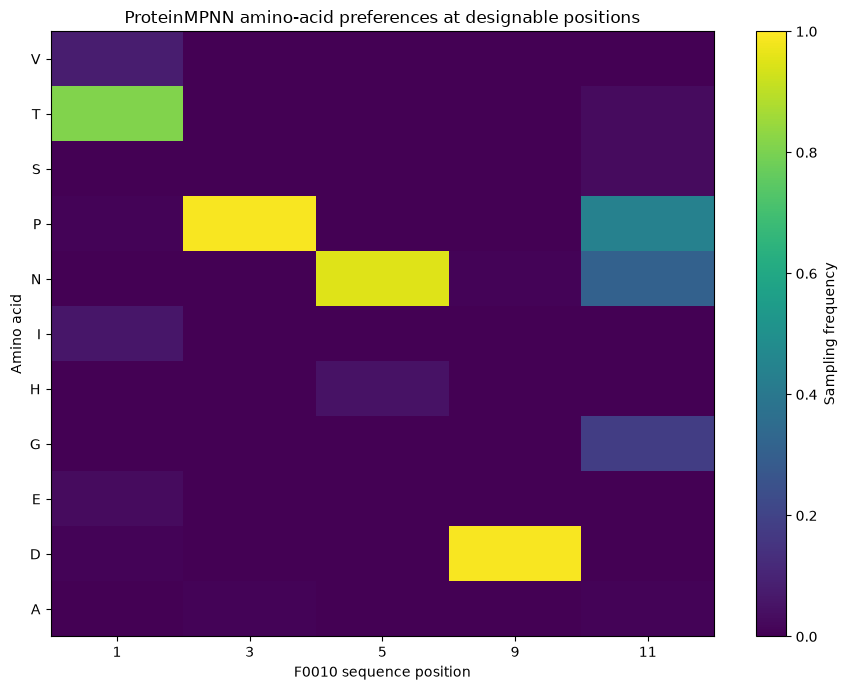

In [23]:
pivot = (
    mutation_frequency_df
    .pivot_table(
        index="sampled_aa",
        columns="position",
        values="frequency",
        fill_value=0.0,
    )
)

plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",
    vmin=0,
    vmax=1,
)

plt.colorbar(
    label="Sampling frequency"
)

plt.xticks(
    range(
        len(pivot.columns)
    ),
    pivot.columns,
)

plt.yticks(
    range(
        len(pivot.index)
    ),
    pivot.index,
)

plt.xlabel(
    "F0010 sequence position"
)
plt.ylabel(
    "Amino acid"
)
plt.title(
    "ProteinMPNN amino-acid preferences at designable positions"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "08b_position_amino_acid_frequency.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()


## 24. Check recovery of known CLEAR solutions

A useful convergence test is whether ProteinMPNN independently samples:

```text
CF02 = IGERSQYRELK
CF06 = IGERCQYRELR
```

Both candidates obey the fixed-hotspot constraints.


In [24]:
known_solution_summary = pd.DataFrame([
    {
        "candidate": "F0010",
        "sequence": F0010_SEQUENCE,
        "sampled_by_ProteinMPNN": bool(
            (
                unique_designs_df[
                    "peptide_sequence"
                ]
                == F0010_SEQUENCE
            ).any()
        ),
    },
    {
        "candidate": "CF06",
        "sequence": "IGERCQYRELR",
        "sampled_by_ProteinMPNN": bool(
            (
                unique_designs_df[
                    "peptide_sequence"
                ]
                == "IGERCQYRELR"
            ).any()
        ),
    },
    {
        "candidate": "CF02",
        "sequence": "IGERSQYRELK",
        "sampled_by_ProteinMPNN": bool(
            (
                unique_designs_df[
                    "peptide_sequence"
                ]
                == "IGERSQYRELK"
            ).any()
        ),
    },
])

display(
    known_solution_summary
)

known_solution_summary.to_csv(
    TABLE_DIR
    / "08b_known_candidate_recovery.csv",
    index=False,
)


,candidate,sequence,sampled_by_ProteinMPNN
0,F0010,IGERCQYRDLK,False
1,CF06,IGERCQYRELR,False
2,CF02,IGERSQYRELK,False


## 25. Create a short-list for 08c

In [25]:
# Exclude very distant designs for the first integration pass.
MAX_HAMMING_FOR_SHORTLIST = 4
TOP_N_SHORTLIST = 20

shortlist_df = (
    unique_designs_df[
        unique_designs_df[
            "min_hamming_vs_F0010"
        ]
        <= MAX_HAMMING_FOR_SHORTLIST
    ]
    .head(
        TOP_N_SHORTLIST
    )
    .copy()
)

shortlist_df.to_csv(
    TABLE_DIR
    / "08b_ProteinMPNN_shortlist_for_08c.csv",
    index=False,
)

print(
    "Shortlist size:",
    len(shortlist_df),
)

display(
    shortlist_df
)


Shortlist size: 20


,ProteinMPNN_rank,peptide_sequence,sample_count,best_ProteinMPNN_score,mean_ProteinMPNN_score,best_global_score,min_hamming_vs_F0010,matches_F0010,matches_CF06,matches_CF02
0,1,TGPRNQYRDLP,34,1.2473,1.300118,1.5296,4,False,False,False
1,2,TGPRNQYRDLN,25,1.2479,1.305864,1.5373,4,False,False,False
2,3,TGPRNQYRDLG,14,1.2572,1.321343,1.5397,4,False,False,False
3,4,VGPRNQYRDLP,3,1.2978,1.314500,1.5479,4,False,False,False
4,5,IGPRNQYRDLN,2,1.3458,1.374800,1.5526,3,False,False,False
5,6,VGPRNQYRDLN,2,1.3525,1.376000,1.5445,4,False,False,False
6,7,TGPRNQYRDLS,2,1.3576,1.360850,1.5393,4,False,False,False
7,8,IGPRNQYRDLG,1,1.3662,1.366200,1.5476,3,False,False,False
8,9,TGPRNQYRDLT,2,1.3831,1.422550,1.5397,4,False,False,False
9,10,IGPRNQYRDLP,1,1.3881,1.388100,1.5462,3,False,False,False


## 26. Automatic QC

The notebook requires:

```text
input F0010 sequence correct
chain D designed
fixed hotspot positions preserved
at least one generated sequence
```


In [26]:
qc_rows = [
    {
        "check": "input_peptide_is_F0010",
        "pass": (
            observed_peptide_sequence
            == F0010_SEQUENCE
        ),
    },
    {
        "check": "generated_sequences_present",
        "pass": (
            len(generated_df) > 0
        ),
    },
    {
        "check": "fixed_hotspots_preserved",
        "pass": bool(
            fixed_validation_df[
                "all_fixed_positions_preserved"
            ].all()
        ),
    },
    {
        "check": "unique_designs_present",
        "pass": (
            len(unique_designs_df) > 0
        ),
    },
]

qc_df = pd.DataFrame(
    qc_rows
)

display(qc_df)

ALL_QC_PASSED = bool(
    qc_df["pass"].all()
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "08b_QC.csv",
    index=False,
)


,check,pass
0,input_peptide_is_F0010,True
1,generated_sequences_present,True
2,fixed_hotspots_preserved,True
3,unique_designs_present,True


ALL QC PASSED: True


## 27. Automatic report

In [27]:
top_design = (
    unique_designs_df.iloc[0]
    if len(unique_designs_df)
    else None
)

report_lines = [
    "# 08b - ProteinMPNN Structure-Conditioned Peptide Design",
    "",
    f"- ProteinMPNN git hash: {PROTEINMPNN_GIT_HASH}",
    f"- Model: {MODEL_NAME}",
    f"- Mode: {RUN_LABEL}",
    f"- Sampling temperatures: {SAMPLING_TEMPERATURES}",
    f"- Generated records: {len(generated_df)}",
    f"- Unique peptide designs: {len(unique_designs_df)}",
    "",
    "## Design constraints",
    f"- Receptor chain fixed: {RECEPTOR_CHAIN}",
    f"- Designed peptide chain: {PEPTIDE_CHAIN}",
    f"- Fixed peptide positions: {FIXED_PEPTIDE_POSITIONS}",
    f"- Designable peptide positions: {DESIGNABLE_PEPTIDE_POSITIONS}",
    "",
    "## Known-solution recovery",
]

for row in known_solution_summary.itertuples():
    report_lines.append(
        f"- {row.candidate}: sampled={row.sampled_by_ProteinMPNN}"
    )

if top_design is not None:
    report_lines.extend([
        "",
        "## Top ProteinMPNN design",
        (
            f"- sequence: {top_design['peptide_sequence']}"
        ),
        (
            f"- best ProteinMPNN score: "
            f"{top_design['best_ProteinMPNN_score']:.4f}"
        ),
        (
            f"- Hamming distance vs F0010: "
            f"{top_design['min_hamming_vs_F0010']}"
        ),
    ])

report_lines.extend([
    "",
    "## Interpretation",
    (
        "ProteinMPNN provides structure-conditioned sequence proposals. "
        "Its score is not a receptor-binding free energy."
    ),
    (
        "Candidates should be prioritized by convergence with ESM-2, "
        "CLEAR, structural refinement, MD and energetic analyses."
    ),
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "08b_ProteinMPNN_design_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 08b - ProteinMPNN Structure-Conditioned Peptide Design

- ProteinMPNN git hash: 8907e6671bfbfc92303b5f79c4b5e6ce47cdef57
- Model: v_48_020
- Mode: production
- Sampling temperatures: 0.1 0.2
- Generated records: 100
- Unique peptide designs: 24

## Design constraints
- Receptor chain fixed: B
- Designed peptide chain: D
- Fixed peptide positions: [2, 4, 6, 7, 8, 10]
- Designable peptide positions: [1, 3, 5, 9, 11]

## Known-solution recovery
- F0010: sampled=False
- CF06: sampled=False
- CF02: sampled=False

## Top ProteinMPNN design
- sequence: TGPRNQYRDLP
- best ProteinMPNN score: 1.2473
- Hamming distance vs F0010: 4

## Interpretation
ProteinMPNN provides structure-conditioned sequence proposals. Its score is not a receptor-binding free energy.
Candidates should be prioritized by convergence with ESM-2, CLEAR, structural refinement, MD and energetic analyses.

Report: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08b_proteinmpnn/production/reports/08b_ProteinMPNN_desi

# 28. How to run this notebook

Start with:

```python
FAST_TEST_MODE = True
```

This generates a small set of sequences and verifies the complete workflow.

If:

```text
ALL QC PASSED: True
```

rerun with:

```python
FAST_TEST_MODE = False
```

The production mode increases sequence sampling and uses two sampling
temperatures:

```text
0.1
0.2
```

Higher sampling temperatures increase diversity.

---

# 29. Next step — 08c

The next notebook will integrate:

```text
ProteinMPNN shortlist
+
ESM-2 scoring
+
CLEAR overlap
+
07d MD evidence
+
07e endpoint energy
```

to determine whether ProteinMPNN:

1. independently recovers CF02 or CF06;
2. generates new local candidates;
3. agrees with ESM-2 at specific mutable positions;
4. suggests a small number of genuinely new candidates for structural validation.
